# Phase 1: EMSCAD Dataset Analysis

This notebook verifies and explores the original EMSCAD dataset for the dissertation project **An Intelligent Framework for Detection of AI-Generated Fraudulent Job Postings in Online Recruitment**.

Phase 1 is limited to dataset understanding and project preparation. It does **not** generate AI-written scams, train transformer models, evaluate classifiers, perform robustness testing, or build an application.

## 1. Imports

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Dataset Loading

The expected Phase 1 dataset path is `data/raw/emscad.csv`. The raw dataset is loaded read-only; this notebook writes only analysis outputs under `results/`.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "emscad.csv"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
PLOT_DIR = PROJECT_ROOT / "results" / "plots"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"EMSCAD dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {DATA_PATH}")

Loaded dataset: C:\Users\Rajesh Singh\Desktop\Fraud Detection\AI_Job_Fraud_Detection\data\raw\emscad.csv


## 3. Dataset Dimensions

In [3]:
rows, columns = df.shape
dataset_summary = pd.DataFrame([
    {"metric": "rows", "value": rows},
    {"metric": "columns", "value": columns},
    {"metric": "source_path", "value": str(DATA_PATH.relative_to(PROJECT_ROOT))},
])
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)
dataset_summary

,metric,value
0,rows,17880
1,columns,18
2,source_path,data\raw\emscad.csv


## 4. Column Names

In [4]:
column_names = pd.DataFrame({"column": df.columns})
column_names.to_csv(TABLE_DIR / "column_names.csv", index=False)
column_names

,column
0,title
1,location
2,department
3,salary_range
4,company_profile
5,description
6,requirements
7,benefits
8,telecommuting
9,has_company_logo


## 5. Data Types

In [5]:
column_dtypes = df.dtypes.astype(str).reset_index()
column_dtypes.columns = ["column", "dtype"]
column_dtypes.to_csv(TABLE_DIR / "column_dtypes.csv", index=False)
column_dtypes

,column,dtype
0,title,object
1,location,object
2,department,object
3,salary_range,object
4,company_profile,object
5,description,object
6,requirements,object
7,benefits,object
8,telecommuting,object
9,has_company_logo,object


## 6. First Few Records

In [6]:
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebr...","<p>Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub,...",<ul>\r\n<li>Experience with content management systems a major plus (any blogging counts!)</li>\r\n<li>Familiar with...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Production Service.</h3>\r\n<p>90 Seconds is the worlds Cloud Video Productio...",<p>Organised - Focused - Vibrant - Awesome!<br><br>Do you have a passion for customer service? Slick typing skills? ...,"<p><b>What we expect from you:</b></p>\r\n<p>Your key responsibility will be to communicate with the client, 90 Seco...",<h3><b>What you will get from us</b></h3>\r\n<p>Through being part of the 90 Seconds team you will gain:</p>\r\n<ul>...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workforce Solutions that meet the needs of companies across the Private Sect...,"<p>Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assistant that possess...",<ul>\r\n<li>Implement pre-commissioning and commissioning procedures for rotary equipment.</li>\r\n<li>Execute all a...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life through geography is at the heart of everything we do. Esri’s geograph...,<p><b>THE COMPANY: ESRI – Environmental Systems Research Institute</b></p>\r\n<p>Our passion for improving quality o...,"<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s or Master’s in GIS, business administration, or a related field, or equ...","<p>Our culture is anything but corporate—we have a collaborative, creative environment; phone directories organized ...",f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,"<p>SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered in Miami, Florida. Fo...","<p><b>JOB TITLE:</b> Itemization Review Manager</p>\r\n<p><b>LOCATION:</b> Fort Worth, TX<b> ...",<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>RN license in the State of Texas</li>\r\n<li>Diploma or Bachelors of Sc...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


## 7. Dataset Information

In [7]:
info_table = pd.DataFrame({
    "column": df.columns,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns],
})
info_table.to_csv(TABLE_DIR / "dataset_info.csv", index=False)
info_table

,column,non_null_count,null_count,dtype,unique_values
0,title,17880,0,object,11231
1,location,17534,346,object,3105
2,department,6333,11547,object,1337
3,salary_range,2868,15012,object,874
4,company_profile,14572,3308,object,1710
5,description,17880,0,object,15095
6,requirements,15191,2689,object,12119
7,benefits,10684,7196,object,6510
8,telecommuting,17880,0,object,2
9,has_company_logo,17880,0,object,2


## 8. Missing-Value Analysis

Missing values are documented only. No columns or rows are removed in Phase 1.

In [8]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(4),
}).sort_values("missing_percentage", ascending=False)

missing_values.to_csv(TABLE_DIR / "missing_values.csv", index=False)
missing_values

,column,missing_count,missing_percentage
3,salary_range,15012,83.9597
2,department,11547,64.5805
13,required_education,8105,45.3300
7,benefits,7196,40.2461
12,required_experience,7050,39.4295
15,function,6455,36.1018
14,industry,4903,27.4217
11,employment_type,3471,19.4128
4,company_profile,3308,18.5011
6,requirements,2689,15.0391


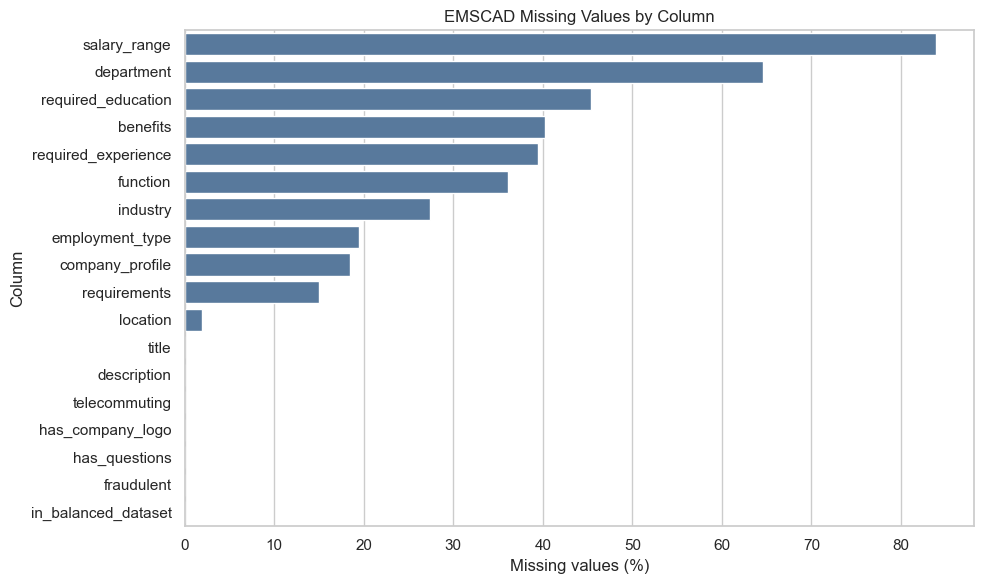

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_values, y="column", x="missing_percentage", color="#4C78A8")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("EMSCAD Missing Values by Column")
plt.tight_layout()
plt.savefig(PLOT_DIR / "missing_values_by_column.png", dpi=160)
plt.show()

## 9. Duplicate Analysis

Duplicates are counted and documented. The raw dataset is not deduplicated in Phase 1.

In [10]:
def duplicate_metrics(series: pd.Series) -> dict:
    cleaned = series.dropna().astype(str).str.strip()
    cleaned = cleaned[cleaned != ""]
    duplicated_mask = cleaned.duplicated(keep=False)
    return {
        "non_empty_records": int(len(cleaned)),
        "duplicate_records_after_first": int(cleaned.duplicated().sum()),
        "records_in_duplicate_groups": int(duplicated_mask.sum()),
        "duplicate_groups": int(cleaned[duplicated_mask].nunique()),
    }

duplicate_rows = []
duplicate_rows.append({"check": "exact_duplicate_rows", "value": int(df.duplicated().sum()), "notes": "Full-row duplicates; not removed in Phase 1."})

for col in ["description", "title", "company_profile", "requirements", "benefits"]:
    if col in df.columns:
        metrics = duplicate_metrics(df[col])
        for metric, value in metrics.items():
            duplicate_rows.append({"check": f"{col}_{metric}", "value": value, "notes": "Computed after stripping whitespace and excluding null/empty strings."})

id_candidates = [col for col in df.columns if col.lower() in {"id", "job_id", "posting_id"} or col.lower().endswith("_id")]
if id_candidates:
    for col in id_candidates:
        duplicate_rows.append({"check": f"{col}_duplicate_ids", "value": int(df[col].duplicated().sum()), "notes": "Potential ID column."})
else:
    duplicate_rows.append({"check": "id_column_detected", "value": 0, "notes": "No obvious ID column was found."})

duplicate_analysis = pd.DataFrame(duplicate_rows)
duplicate_analysis.to_csv(TABLE_DIR / "duplicate_analysis.csv", index=False)
duplicate_analysis

,check,value,notes
0,exact_duplicate_rows,235,Full-row duplicates; not removed in Phase 1.
1,description_non_empty_records,17880,Computed after stripping whitespace and excluding null/empty strings.
2,description_duplicate_records_after_first,2785,Computed after stripping whitespace and excluding null/empty strings.
3,description_records_in_duplicate_groups,3837,Computed after stripping whitespace and excluding null/empty strings.
4,description_duplicate_groups,1052,Computed after stripping whitespace and excluding null/empty strings.
5,title_non_empty_records,17880,Computed after stripping whitespace and excluding null/empty strings.
6,title_duplicate_records_after_first,6965,Computed after stripping whitespace and excluding null/empty strings.
7,title_records_in_duplicate_groups,8704,Computed after stripping whitespace and excluding null/empty strings.
8,title_duplicate_groups,1739,Computed after stripping whitespace and excluding null/empty strings.
9,company_profile_non_empty_records,14572,Computed after stripping whitespace and excluding null/empty strings.


## 10. Target/Class Distribution

The target column is identified from the dataset. For EMSCAD, `fraudulent` contains `f` and `t`, which are interpreted as legitimate and fraudulent after inspecting the observed values.

In [11]:
def find_target_column(frame: pd.DataFrame) -> str:
    exact_candidates = ["fraudulent", "fraud", "label", "target", "class"]
    lower_to_original = {col.lower(): col for col in frame.columns}
    for candidate in exact_candidates:
        if candidate in lower_to_original:
            return lower_to_original[candidate]
    contains_fraud = [col for col in frame.columns if "fraud" in col.lower()]
    if contains_fraud:
        return contains_fraud[0]
    raise ValueError("Could not identify a fraud/target label column from the dataset columns.")

def normalize_fraud_label(value):
    if pd.isna(value):
        return "Missing"
    text = str(value).strip().lower()
    if text in {"t", "true", "1", "yes", "y", "fraud", "fraudulent"}:
        return "Fraudulent"
    if text in {"f", "false", "0", "no", "n", "legit", "legitimate", "real"}:
        return "Legitimate"
    return f"Unexpected: {value}"

TARGET_COLUMN = find_target_column(df)
target_unique_values = (
    df[TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("raw_target_value")
    .reset_index(name="count")
)
target_unique_values["percentage"] = (target_unique_values["count"] / len(df) * 100).round(4)
target_unique_values.to_csv(TABLE_DIR / "target_unique_values.csv", index=False)

working = df.copy()
working["target_label"] = working[TARGET_COLUMN].apply(normalize_fraud_label)

class_distribution = (
    working["target_label"]
    .value_counts(dropna=False)
    .rename_axis("class_label")
    .reset_index(name="count")
)
class_distribution["percentage"] = (class_distribution["count"] / len(working) * 100).round(4)
class_distribution["expected_count_from_proposal"] = class_distribution["class_label"].map({"Legitimate": 17014, "Fraudulent": 866})
class_distribution["difference_from_expected"] = class_distribution["count"] - class_distribution["expected_count_from_proposal"]
class_distribution.to_csv(TABLE_DIR / "class_distribution.csv", index=False)

legit_count = int(class_distribution.loc[class_distribution["class_label"].eq("Legitimate"), "count"].iloc[0])
fraud_count = int(class_distribution.loc[class_distribution["class_label"].eq("Fraudulent"), "count"].iloc[0])
imbalance_ratio = legit_count / fraud_count if fraud_count else np.nan

print(f"Target column: {TARGET_COLUMN}")
print(f"Class imbalance ratio, legitimate:fraudulent = {imbalance_ratio:.2f}:1")
display(target_unique_values)
class_distribution

Target column: fraudulent
Class imbalance ratio, legitimate:fraudulent = 19.65:1


,raw_target_value,count,percentage
0,f,17014,95.1566
1,t,866,4.8434


,class_label,count,percentage,expected_count_from_proposal,difference_from_expected
0,Legitimate,17014,95.1566,17014,0
1,Fraudulent,866,4.8434,866,0


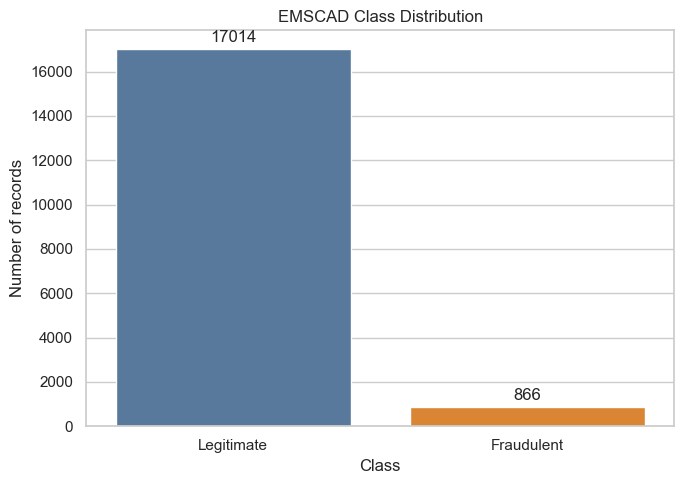

In [12]:
plt.figure(figsize=(7, 5))
plot_data = class_distribution[class_distribution["class_label"].isin(["Legitimate", "Fraudulent"])]
ax = sns.barplot(data=plot_data, x="class_label", y="count", palette=["#4C78A8", "#F58518"], hue="class_label", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.xlabel("Class")
plt.ylabel("Number of records")
plt.title("EMSCAD Class Distribution")
plt.tight_layout()
plt.savefig(PLOT_DIR / "class_distribution.png", dpi=160)
plt.show()

## 11. Text-Length Analysis

Major recruitment text fields are analyzed separately from metadata. Counts below are based on raw EMSCAD text, which includes HTML markup in several fields. HTML cleaning is intentionally deferred to a later preprocessing phase.

In [13]:
MAJOR_TEXT_FIELDS = [field for field in ["title", "company_profile", "description", "requirements", "benefits"] if field in df.columns]
OTHER_TEXT_FIELDS = [field for field in ["location", "department", "employment_type", "required_experience", "required_education", "industry", "function", "salary_range"] if field in df.columns]

word_pattern = re.compile(r"\b\w+\b")

def cleaned_text(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip()

def word_count_value(value) -> int:
    if pd.isna(value):
        return 0
    return len(word_pattern.findall(str(value)))

text_stat_rows = []
for field in MAJOR_TEXT_FIELDS + OTHER_TEXT_FIELDS:
    values = cleaned_text(df[field])
    non_empty = values.dropna()
    non_empty = non_empty[non_empty != ""]
    char_counts = non_empty.str.len()
    word_counts = non_empty.apply(word_count_value)
    text_stat_rows.append({
        "column": field,
        "non_null_records": int(df[field].notna().sum()),
        "non_empty_records": int(len(non_empty)),
        "missing_count": int(df[field].isna().sum()),
        "empty_or_whitespace_count": int((df[field].notna() & df[field].astype(str).str.strip().eq("")).sum()),
        "char_min": int(char_counts.min()) if len(char_counts) else 0,
        "char_max": int(char_counts.max()) if len(char_counts) else 0,
        "char_mean": round(float(char_counts.mean()), 2) if len(char_counts) else 0,
        "char_median": round(float(char_counts.median()), 2) if len(char_counts) else 0,
        "word_min": int(word_counts.min()) if len(word_counts) else 0,
        "word_max": int(word_counts.max()) if len(word_counts) else 0,
        "word_mean": round(float(word_counts.mean()), 2) if len(word_counts) else 0,
        "word_median": round(float(word_counts.median()), 2) if len(word_counts) else 0,
    })

text_statistics = pd.DataFrame(text_stat_rows)
text_statistics.to_csv(TABLE_DIR / "text_statistics.csv", index=False)
text_statistics

,column,non_null_records,non_empty_records,missing_count,empty_or_whitespace_count,char_min,char_max,char_mean,char_median,word_min,word_max,word_mean,word_median
0,title,17880,17880,0,0,3,142,28.40,25.0,1,19,3.73,3.0
1,company_profile,14572,14572,3308,0,16,6450,851.30,709.0,3,959,131.39,109.0
2,description,17880,17880,0,0,10,55130,1438.56,1158.0,4,6800,217.91,180.0
3,requirements,15191,15191,2689,0,8,37994,860.85,667.0,2,4850,130.40,104.0
4,benefits,10684,10684,7196,0,6,19455,448.19,287.0,1,2366,70.36,46.0
5,location,17534,17534,346,0,2,161,15.47,15.0,1,22,3.06,3.0
6,department,6333,6327,11547,6,1,255,10.55,10.0,1,39,1.40,1.0
7,employment_type,14409,14409,3471,0,5,9,8.83,9.0,1,2,1.86,2.0
8,required_experience,10830,10830,7050,0,8,16,12.47,11.0,1,3,2.06,2.0
9,required_education,9775,9775,8105,0,9,33,17.77,17.0,1,4,2.85,3.0


In [14]:
class_text_rows = []
for field in MAJOR_TEXT_FIELDS:
    temp = working[[field, "target_label"]].copy()
    temp[field] = cleaned_text(temp[field])
    temp = temp[temp[field].notna() & temp[field].ne("")]
    temp["char_count"] = temp[field].str.len()
    temp["word_count"] = temp[field].apply(word_count_value)
    for label, group in temp.groupby("target_label"):
        class_text_rows.append({
            "column": field,
            "class_label": label,
            "non_empty_records": int(len(group)),
            "char_min": int(group["char_count"].min()) if len(group) else 0,
            "char_max": int(group["char_count"].max()) if len(group) else 0,
            "char_mean": round(float(group["char_count"].mean()), 2) if len(group) else 0,
            "char_median": round(float(group["char_count"].median()), 2) if len(group) else 0,
            "word_min": int(group["word_count"].min()) if len(group) else 0,
            "word_max": int(group["word_count"].max()) if len(group) else 0,
            "word_mean": round(float(group["word_count"].mean()), 2) if len(group) else 0,
            "word_median": round(float(group["word_count"].median()), 2) if len(group) else 0,
        })

text_statistics_by_class = pd.DataFrame(class_text_rows)
text_statistics_by_class.to_csv(TABLE_DIR / "text_statistics_by_class.csv", index=False)
text_statistics_by_class

,column,class_label,non_empty_records,char_min,char_max,char_mean,char_median,word_min,word_max,word_mean,word_median
0,title,Fraudulent,866,3,142,30.43,28.0,1,17,4.12,3.0
1,title,Legitimate,17014,3,109,28.29,25.0,1,19,3.71,3.0
2,company_profile,Fraudulent,279,54,1848,948.71,725.0,11,252,128.92,112.0
3,company_profile,Legitimate,14293,16,6450,849.39,709.0,3,959,131.44,108.0
4,description,Fraudulent,866,10,29424,1436.40,975.5,4,2430,200.65,144.0
5,description,Legitimate,17014,42,55130,1438.67,1166.0,10,6800,218.79,182.0
6,requirements,Fraudulent,713,10,4734,622.32,424.0,4,656,93.07,65.0
7,requirements,Legitimate,14478,8,37994,872.60,676.5,2,4850,132.24,105.0
8,benefits,Fraudulent,503,10,3208,439.76,244.0,3,489,66.24,37.0
9,benefits,Legitimate,10181,6,19455,448.60,289.0,1,2366,70.56,47.0


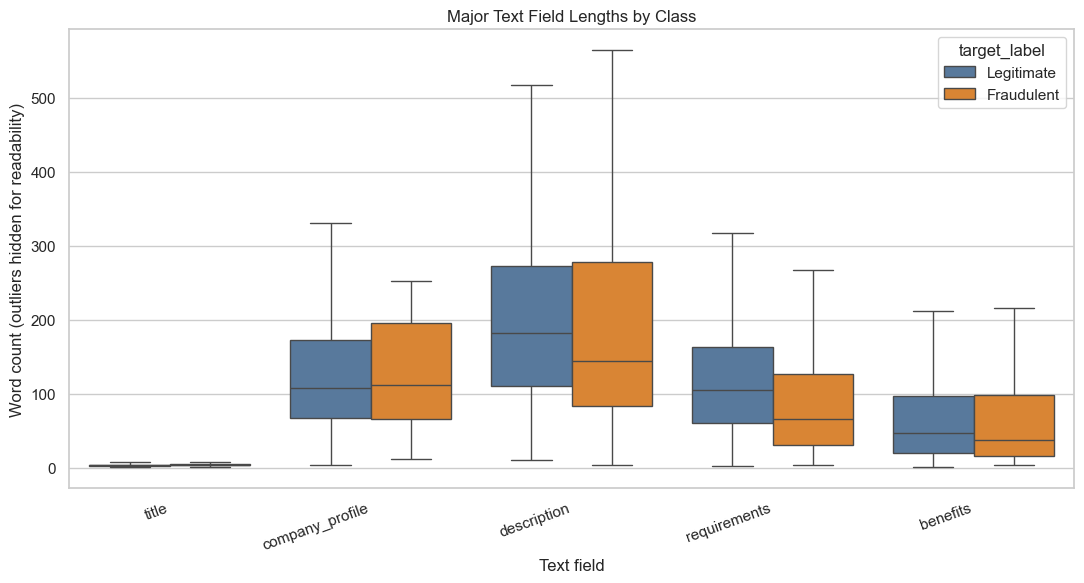

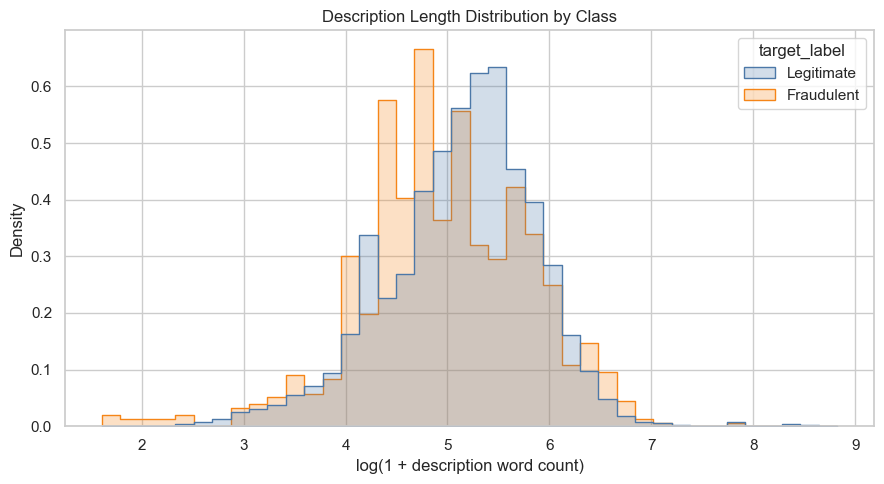

In [15]:
plot_rows = []
for field in MAJOR_TEXT_FIELDS:
    temp = working[[field, "target_label"]].copy()
    temp[field] = cleaned_text(temp[field])
    temp = temp[temp[field].notna() & temp[field].ne("")]
    temp["word_count"] = temp[field].apply(word_count_value)
    temp["field"] = field
    plot_rows.append(temp[["field", "target_label", "word_count"]])

text_plot_data = pd.concat(plot_rows, ignore_index=True) if plot_rows else pd.DataFrame(columns=["field", "target_label", "word_count"])

plt.figure(figsize=(11, 6))
sns.boxplot(data=text_plot_data, x="field", y="word_count", hue="target_label", showfliers=False, palette=["#4C78A8", "#F58518"])
plt.xlabel("Text field")
plt.ylabel("Word count (outliers hidden for readability)")
plt.title("Major Text Field Lengths by Class")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "major_text_word_counts_by_class.png", dpi=160)
plt.show()

if "description" in MAJOR_TEXT_FIELDS:
    desc_plot = text_plot_data[text_plot_data["field"].eq("description")].copy()
    desc_plot["log_word_count"] = np.log1p(desc_plot["word_count"])
    plt.figure(figsize=(9, 5))
    sns.histplot(data=desc_plot, x="log_word_count", hue="target_label", bins=40, element="step", stat="density", common_norm=False, palette=["#4C78A8", "#F58518"])
    plt.xlabel("log(1 + description word count)")
    plt.ylabel("Density")
    plt.title("Description Length Distribution by Class")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "description_word_count_distribution_by_class.png", dpi=160)
    plt.show()

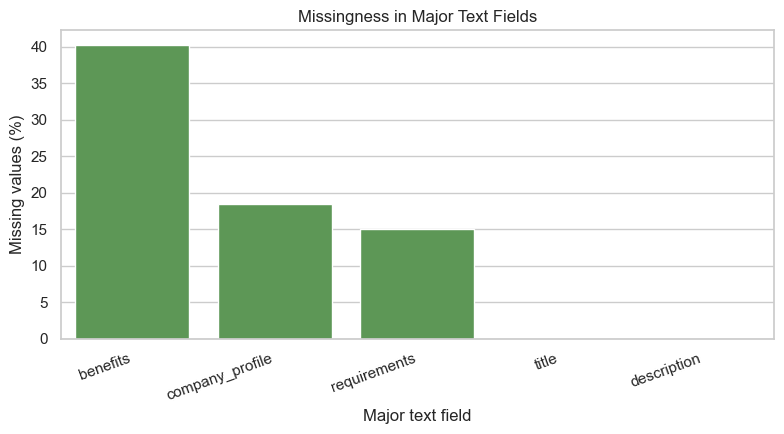

In [16]:
major_missing = missing_values[missing_values["column"].isin(MAJOR_TEXT_FIELDS)].copy()
plt.figure(figsize=(8, 4.5))
sns.barplot(data=major_missing, x="column", y="missing_percentage", color="#54A24B")
plt.xlabel("Major text field")
plt.ylabel("Missing values (%)")
plt.title("Missingness in Major Text Fields")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "major_text_missingness.png", dpi=160)
plt.show()

## 12. Basic Categorical Analysis

In [17]:
categorical_fields = [field for field in OTHER_TEXT_FIELDS + ["telecommuting", "has_company_logo", "has_questions", "in_balanced_dataset"] if field in df.columns]
cat_rows = []
for field in categorical_fields:
    counts = df[field].fillna("<missing>").astype(str).str.strip().replace("", "<empty>").value_counts(dropna=False).head(15)
    for value, count in counts.items():
        cat_rows.append({
            "column": field,
            "value": value,
            "count": int(count),
            "percentage": round(float(count / len(df) * 100), 4),
        })

categorical_top_values = pd.DataFrame(cat_rows)
categorical_top_values.to_csv(TABLE_DIR / "categorical_top_values.csv", index=False)
categorical_top_values.head(60)

,column,value,count,percentage
0,location,"GB, LND, London",736,4.1163
1,location,"US, NY, New York",674,3.7696
2,location,"US, CA, San Francisco",479,2.6790
3,location,"GR, I, Athens",469,2.6230
4,location,<missing>,346,1.9351
5,location,"US, ,",339,1.8960
6,location,"US, TX, Houston",270,1.5101
7,location,"US, IL, Chicago",256,1.4318
8,location,"US, DC, Washington",251,1.4038
9,location,"NZ, N, Auckland",224,1.2528


## 13. Data-Quality Checks

These checks identify issues to consider during later preprocessing. No cleaning is applied here.

In [18]:
object_columns = df.select_dtypes(include=["object"]).columns.tolist()
empty_counts = {col: int((df[col].notna() & df[col].astype(str).eq("")).sum()) for col in object_columns}
whitespace_counts = {col: int((df[col].notna() & df[col].astype(str).str.strip().eq("")).sum()) for col in object_columns}

def contains_pattern_any(row, pattern: str) -> bool:
    return any(bool(re.search(pattern, str(value))) for value in row.dropna())

major_text_frame = df[MAJOR_TEXT_FIELDS].copy() if MAJOR_TEXT_FIELDS else pd.DataFrame(index=df.index)
all_major_text_empty = major_text_frame.apply(lambda row: all(pd.isna(v) or str(v).strip() == "" for v in row), axis=1).sum() if MAJOR_TEXT_FIELDS else 0
html_tag_records = major_text_frame.apply(lambda row: contains_pattern_any(row, r"<[^>]+>"), axis=1).sum() if MAJOR_TEXT_FIELDS else 0
replacement_char_records = major_text_frame.apply(lambda row: any("?" in str(value) for value in row.dropna()), axis=1).sum() if MAJOR_TEXT_FIELDS else 0
unexpected_target_records = int((~working["target_label"].isin(["Legitimate", "Fraudulent"])).sum())

quality_rows = [
    {"check": "object_columns_with_empty_strings", "value": sum(count > 0 for count in empty_counts.values()), "notes": "Columns containing explicit empty strings."},
    {"check": "total_empty_string_cells", "value": int(sum(empty_counts.values())), "notes": "Does not include NaN values."},
    {"check": "total_empty_or_whitespace_cells", "value": int(sum(whitespace_counts.values())), "notes": "Whitespace-only cells included; NaN excluded."},
    {"check": "records_with_all_major_text_fields_empty", "value": int(all_major_text_empty), "notes": "Major text fields are title, company_profile, description, requirements, benefits where present."},
    {"check": "records_with_html_tags_in_major_text", "value": int(html_tag_records), "notes": "HTML markup is present in raw text and should be handled in preprocessing."},
    {"check": "records_with_replacement_character_in_major_text", "value": int(replacement_char_records), "notes": "May indicate encoding artifacts in raw text."},
    {"check": "unexpected_target_records", "value": unexpected_target_records, "notes": "Target values outside the interpreted legitimate/fraudulent mapping."},
    {"check": "exact_duplicate_rows", "value": int(df.duplicated().sum()), "notes": "Documented only; raw dataset unchanged."},
]

if "description" in df.columns:
    desc_clean = cleaned_text(df["description"]).dropna()
    desc_clean = desc_clean[desc_clean != ""]
    repeated_desc_5_plus = int((desc_clean.value_counts() >= 5).sum())
    quality_rows.append({"check": "description_values_repeated_5_plus_times", "value": repeated_desc_5_plus, "notes": "Suspiciously repeated advertisements may require review later."})

if "title" in df.columns:
    title_clean = cleaned_text(df["title"]).dropna()
    title_clean = title_clean[title_clean != ""]
    repeated_title_20_plus = int((title_clean.value_counts() >= 20).sum())
    quality_rows.append({"check": "title_values_repeated_20_plus_times", "value": repeated_title_20_plus, "notes": "Common titles are expected, but high repetition may affect splitting/evaluation."})

if id_candidates:
    for col in id_candidates:
        quality_rows.append({"check": f"duplicate_id_values_in_{col}", "value": int(df[col].duplicated().sum()), "notes": "Potential identifier duplication."})
else:
    quality_rows.append({"check": "obvious_id_column", "value": 0, "notes": "No obvious ID column detected."})

data_quality_checks = pd.DataFrame(quality_rows)
data_quality_checks.to_csv(TABLE_DIR / "data_quality_checks.csv", index=False)
data_quality_checks

,check,value,notes
0,object_columns_with_empty_strings,0,Columns containing explicit empty strings.
1,total_empty_string_cells,0,Does not include NaN values.
2,total_empty_or_whitespace_cells,6,Whitespace-only cells included; NaN excluded.
3,records_with_all_major_text_fields_empty,0,"Major text fields are title, company_profile, description, requirements, benefits where present."
4,records_with_html_tags_in_major_text,17863,HTML markup is present in raw text and should be handled in preprocessing.
5,records_with_replacement_character_in_major_text,4304,May indicate encoding artifacts in raw text.
6,unexpected_target_records,0,Target values outside the interpreted legitimate/fraudulent mapping.
7,exact_duplicate_rows,235,Documented only; raw dataset unchanged.
8,description_values_repeated_5_plus_times,137,Suspiciously repeated advertisements may require review later.
9,title_values_repeated_20_plus_times,54,"Common titles are expected, but high repetition may affect splitting/evaluation."


## 14. Text vs Metadata Assessment

This table separates recruitment text from metadata and target/preprocessing artifacts. It is a preliminary methodological aid for Phase 2, not a final model-input decision.

In [19]:
def classify_column(column: str) -> tuple[str, str, str]:
    major_text = {"title", "company_profile", "description", "requirements", "benefits"}
    contextual_text = {"location", "department", "employment_type", "required_experience", "required_education", "industry", "function"}
    binary_metadata = {"telecommuting", "has_company_logo", "has_questions"}

    if column == TARGET_COLUMN:
        return "Target", "No", "Class label; must never be included as model input."
    if column == "in_balanced_dataset":
        return "Metadata / preprocessing artifact", "No", "May encode previous balancing/subsetting and could leak experimental design."
    if column in major_text:
        return "Text", "Yes", "Core recruitment text; candidate for future transformer input."
    if column in contextual_text:
        return "Metadata / short text descriptor", "Maybe", "Potentially useful context, but should be reviewed for leakage, sparsity, and fairness concerns."
    if column == "salary_range":
        return "Metadata / structured text", "Maybe", "May be useful but can be sparse and may introduce shortcut learning."
    if column in binary_metadata:
        return "Metadata / binary", "Maybe", "Could be predictive but risks metadata leakage/shortcut learning if mixed into a text-only transformer setup."
    return "Unknown", "Review", "Column role should be manually reviewed before Phase 2."

assessment_rows = []
missing_lookup = missing_values.set_index("column")["missing_percentage"].to_dict()
for column in df.columns:
    category, useful, notes = classify_column(column)
    assessment_rows.append({
        "Column": column,
        "Data Type": str(df[column].dtype),
        "Missing %": missing_lookup.get(column, 0),
        "Text/Metadata": category,
        "Potentially Useful": useful,
        "Notes": notes,
    })

column_methodology_assessment = pd.DataFrame(assessment_rows)
column_methodology_assessment.to_csv(TABLE_DIR / "column_methodology_assessment.csv", index=False)
column_methodology_assessment

,Column,Data Type,Missing %,Text/Metadata,Potentially Useful,Notes
0,title,object,0.0000,Text,Yes,Core recruitment text; candidate for future transformer input.
1,location,object,1.9351,Metadata / short text descriptor,Maybe,"Potentially useful context, but should be reviewed for leakage, sparsity, and fairness concerns."
2,department,object,64.5805,Metadata / short text descriptor,Maybe,"Potentially useful context, but should be reviewed for leakage, sparsity, and fairness concerns."
3,salary_range,object,83.9597,Metadata / structured text,Maybe,May be useful but can be sparse and may introduce shortcut learning.
4,company_profile,object,18.5011,Text,Yes,Core recruitment text; candidate for future transformer input.
5,description,object,0.0000,Text,Yes,Core recruitment text; candidate for future transformer input.
6,requirements,object,15.0391,Text,Yes,Core recruitment text; candidate for future transformer input.
7,benefits,object,40.2461,Text,Yes,Core recruitment text; candidate for future transformer input.
8,telecommuting,object,0.0000,Metadata / binary,Maybe,Could be predictive but risks metadata leakage/shortcut learning if mixed into a text-only transformer setup.
9,has_company_logo,object,0.0000,Metadata / binary,Maybe,Could be predictive but risks metadata leakage/shortcut learning if mixed into a text-only transformer setup.


## 15. Initial Data-Quality Observations

Key observations from Phase 1 should be reviewed before preprocessing:

- The raw dataset contains HTML markup in major text fields; text cleaning should be planned explicitly in Phase 2.
- Missingness is substantial in several fields, especially `salary_range`, `department`, `benefits`, `required_education`, and `company_profile`.
- The dataset is highly imbalanced, with legitimate advertisements outnumbering fraudulent advertisements by roughly 19.65:1.
- Exact duplicate rows and repeated job descriptions/titles exist; these may affect later train/test splitting and evaluation if not handled carefully.
- `in_balanced_dataset` appears to be a preprocessing/subsetting artifact and should not be used as a model feature.
- Binary metadata such as `has_company_logo` and `has_questions` may be predictive, but including them could shift the dissertation away from purely textual fraud detection and introduce shortcut learning.

## 16. Preliminary Recommendation ? Requires Confirmation Before Phase 2

Candidate future transformer input combinations:

**Option A:** `title + description`

- Minimal textual baseline.
- Lower risk of metadata leakage.
- May omit useful context from company profile, requirements, and benefits.

**Option B:** `title + company_profile + description + requirements + benefits`

- Strong textual-only candidate aligned with the dissertation focus.
- Captures the main recruitment narrative without binary or preprocessing metadata.
- Requires careful handling of missing fields and HTML cleaning in Phase 2.

**Option C:** all relevant textual recruitment fields, potentially including short descriptors such as `location`, `department`, `employment_type`, `required_experience`, `required_education`, `industry`, and `function`

- Richest context.
- Higher risk of shortcut learning, location/industry bias, and metadata leakage concerns.

**Preliminary recommendation - requires confirmation before Phase 2:** use Option B as the primary text-only input candidate, with Option A as a baseline. Exclude `fraudulent`, `in_balanced_dataset`, and binary metadata from the first transformer experiments unless there is a deliberate later comparison against metadata-enhanced models.